# Markov chains & Hidden Markov Models — `qufin.markov`

Markets switch between **regimes** — calm and turbulent, trending and ranging,
bull and bear. Markov models are the natural language for regime dynamics.

* A **Markov chain** models an *observed* state sequence with the memoryless
  property: the next state depends only on the current one. The whole model is a
  **transition matrix** $T_{ij}=P(s_{t+1}=j\mid s_t=i)$.
* A **Hidden Markov Model (HMM)** assumes the regime is *latent*: you never see
  "bull" or "bear" directly, only noisy emissions (returns). An HMM couples a
  hidden Markov chain (transition $A$) to an emission distribution ($B$) and an
  initial distribution ($\pi$).

The three classic HMM problems, all implemented here:

| Problem | Question | Algorithm |
|---|---|---|
| **Evaluation** | How likely is this data? | Forward ( `score` ) |
| **Decoding** | What was the hidden path? | Viterbi ( `decode` ) |
| **Learning** | What are $A,B,\pi$? | Baum–Welch EM ( `fit_hmm` ) |

**Roadmap**

1. Markov chains — *provably* recover a transition matrix; stationarity & mixing
2. A real Markov chain — VIX volatility regimes persist
3. Higher-order chains — when one lag of memory isn't enough
4. HMM — recover a hidden 2-regime model and decode it (Viterbi)
5. Unsupervised regimes on real SPY returns — bull/bear detection


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

from qufin.markov import (
    fit_chain, simulate_chain, stationary_distribution, n_step_matrix,
    fit_higher_order, higher_order_log_likelihood,
    fit_hmm, decode, score, simulate_hmm,
)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
rng = np.random.default_rng(0)

def align_labels(true_s, pred_s, k):
    """Best permutation of predicted labels to match truth (Hungarian on confusion)."""
    conf = np.zeros((k, k), dtype=int)
    np.add.at(conf, (true_s, pred_s), 1)
    row, col = linear_sum_assignment(-conf)
    mapping = {int(c): int(r) for r, c in zip(row, col)}
    return np.array([mapping[int(s)] for s in pred_s], dtype=np.intp)


## 1. Markov chains — recover a transition matrix

We define a 3-state market chain — **0: down-trend, 1: range, 2: up-trend** —
with a *sticky* transition matrix (regimes persist, the diagonal dominates).
Simulate a long path, then `fit_chain` recovers the matrix by maximum
likelihood (just normalised transition counts).


In [2]:
STATES = ['down', 'range', 'up']
T_true = np.array([
    [0.85, 0.13, 0.02],   # down -> mostly stays down
    [0.10, 0.80, 0.10],   # range -> symmetric
    [0.02, 0.13, 0.85],   # up   -> mostly stays up
])
seq = simulate_chain(T_true, initial_state=1, n_steps=20000, rng=rng)
fit = fit_chain(seq, n_states=3)

np.set_printoptions(precision=3, suppress=True)
print('true transition matrix:\n', T_true)
print('\nrecovered (MLE):\n', fit.transition_matrix)
print(f'\nmax abs error = {np.abs(fit.transition_matrix - T_true).max():.4f}')


true transition matrix:
 [[0.85 0.13 0.02]
 [0.1  0.8  0.1 ]
 [0.02 0.13 0.85]]

recovered (MLE):
 [[0.859 0.12  0.021]
 [0.098 0.802 0.1  ]
 [0.018 0.144 0.838]]

max abs error = 0.0140


### Stationarity and mixing

The **stationary distribution** $\pi$ solves $\pi T=\pi$ — the long-run
fraction of time spent in each state. The **n-step matrix** $T^n$ shows how a
chain *forgets* its start: every row converges to $\pi$ as $n$ grows (the
mixing time). Sticky chains mix slowly.


stationary distribution pi = [0.303 0.394 0.303]    (empirical: [0.313 0.399 0.288] )


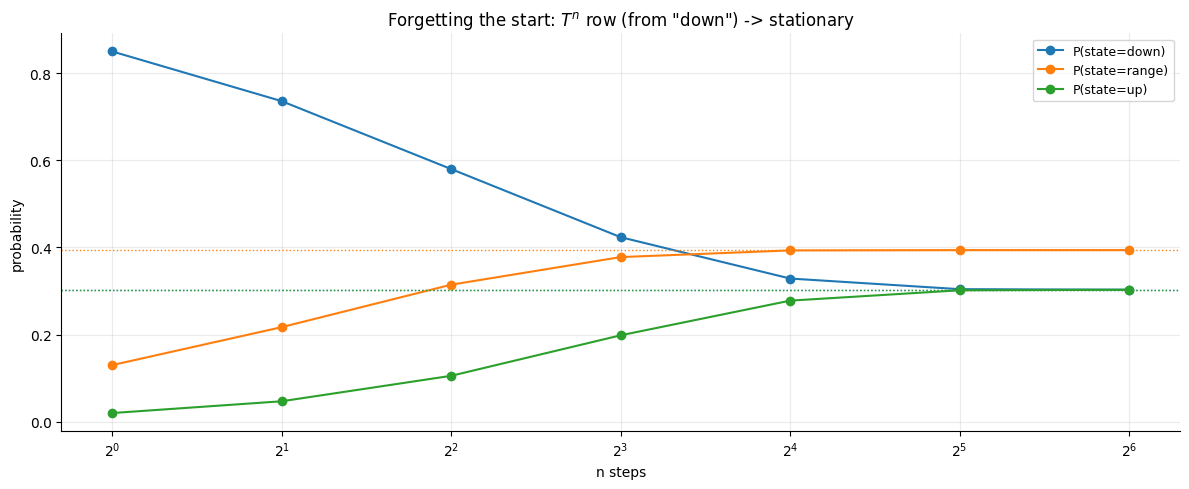

In [3]:
pi = stationary_distribution(T_true)
print('stationary distribution pi =', np.round(pi, 3),
      '   (empirical:', np.round(np.bincount(seq) / len(seq), 3), ')')

ns = [1, 2, 4, 8, 16, 32, 64]
fig, ax = plt.subplots()
rows = np.array([n_step_matrix(T_true, n)[0] for n in ns])  # start in 'down'
for j, s in enumerate(STATES):
    ax.plot(ns, rows[:, j], 'o-', label=f'P(state={s})')
    ax.axhline(pi[j], color=f'C{j}', ls=':', lw=1)
ax.set_xscale('log', base=2); ax.set_title('Forgetting the start: $T^n$ row (from "down") -> stationary')
ax.set_xlabel('n steps'); ax.set_ylabel('probability'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 2. A real Markov chain — VIX volatility regimes

Volatility clusters, so **volatility regimes are highly persistent** — a perfect
real Markov chain. We bucket the VIX into **low (<16), mid, high (>24)** states
and fit a chain. The transition matrix is strongly diagonal (today's regime
predicts tomorrow's), and the stationary distribution recovers the long-run time
spent in each volatility regime.


In [4]:
def load_vix(start='2005-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        v = yf.download('^VIX', start=start, end=end, auto_adjust=True, progress=False)
        v = v['Close'].dropna().to_numpy(dtype='float64').ravel()
        if len(v) > 1000:
            return v
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic VIX')
    x = np.empty(4000); x[0] = np.log(18)
    e = np.random.default_rng(1).normal(0, 0.06, 4000)
    for t in range(1, 4000):
        x[t] = np.log(18) + 0.97 * (x[t-1] - np.log(18)) + e[t]
    return np.exp(x)

vix = load_vix()
regime = np.where(vix < 16, 0, np.where(vix > 24, 2, 1)).astype(np.intp)
LABELS = ['low (<16)', 'mid', 'high (>24)']
cfit = fit_chain(regime, n_states=3)
print('VIX-regime transition matrix:\n', cfit.transition_matrix)
print('\nstationary (long-run time in each regime):')
for lab, p in zip(LABELS, cfit.stationary):
    print(f'  {lab:<12} {p:6.1%}')
print(f'\nexpected duration in a regime = 1/(1-T_ii):',
      {LABELS[i]: round(1/(1-cfit.transition_matrix[i, i]), 1) for i in range(3)})


VIX-regime transition matrix:
 [[0.936 0.064 0.   ]
 [0.084 0.863 0.053]
 [0.    0.096 0.904]]

stationary (long-run time in each regime):
  low (<16)     45.5%
  mid           34.9%
  high (>24)    19.6%

expected duration in a regime = 1/(1-T_ii): {'low (<16)': np.float64(15.5), 'mid': np.float64(7.3), 'high (>24)': np.float64(10.5)}


## 3. Higher-order chains — more memory

A first-order chain forgets everything but the last state. An **order-$N$**
chain conditions on the last $N$ states, capturing longer patterns — at the cost
of $S^{N}(S-1)$ parameters (the curse of dimensionality). We compare the
log-likelihood of order-1 vs order-2 on the VIX-regime sequence; the gain must
beat the extra parameters (BIC) to be worth it.


In [5]:
def bic(ll, n_params, n): return -2 * ll + n_params * np.log(n)

ho1 = fit_chain(regime, n_states=3)
ho2 = fit_higher_order(regime, n_states=3, order=2)
n = len(regime)
ll1, ll2 = ho1.log_likelihood, ho2.log_likelihood
p1, p2 = 3 * 2, 3 * 3 * 2          # S^order * (S-1) free params
print(f'order-1: log-lik={ll1:9.1f}  params={p1:2d}  BIC={bic(ll1, p1, n):9.1f}')
print(f'order-2: log-lik={ll2:9.1f}  params={p2:2d}  BIC={bic(ll2, p2, n):9.1f}')
print(f'\nlog-lik gain = {ll2 - ll1:.1f}; '
      f'order-2 {"justified" if bic(ll2,p2,n) < bic(ll1,p1,n) else "NOT justified"} by BIC.')


order-1: log-lik=  -1725.5  params= 6  BIC=   3502.2
order-2: log-lik=  -1574.3  params=18  BIC=   3302.1

log-lik gain = 151.2; order-2 justified by BIC.


## 4. Hidden Markov Model — recover a latent regime

Now the regime is **hidden**. We build a 2-state HMM — **bull** (mostly *up*
emissions) and **bear** (mostly *down*) — with persistent transitions, simulate
both the hidden states and the observed symbols, then `fit_hmm` (Baum–Welch)
recovers $A,B,\pi$ from the *observations alone*.

Because EM can't know our labels, the recovered states are correct only up to a
permutation — we align them, then measure how well **Viterbi** decoding recovers
the true hidden path.


In [6]:
SYM = ['down', 'flat', 'up']
A_true = np.array([[0.97, 0.03], [0.05, 0.95]])           # 0=bull, 1=bear (sticky)
B_true = np.array([[0.15, 0.25, 0.60],                    # bull emits 'up'
                   [0.55, 0.25, 0.20]])                   # bear emits 'down'
pi_true = np.array([0.9, 0.1])

true_states, obs = simulate_hmm(3000, A_true, B_true, pi_true,
                                rng=np.random.default_rng(7))
model = fit_hmm(obs, n_states=2, n_obs_symbols=3, n_init=10,
                rng=np.random.default_rng(11))

# Align recovered states to the truth via Viterbi decoding.
path = decode(obs, model)
path_aligned = align_labels(true_states, path, 2)
# Apply the same permutation to the parameter matrices for display.
acc = float(np.mean(path_aligned == true_states))
print(f'Baum-Welch converged={model.converged} in {model.n_iter} iters  '
      f'log-lik={model.log_likelihood:.1f}')
print(f'Viterbi state-recovery accuracy = {acc:.1%}')
np.set_printoptions(precision=2, suppress=True)
print('\ntrue transition A:\n', A_true)
print('recovered A (rows may be permuted):\n', model.transition_matrix)
print('\ntrue emissions B:\n', B_true)
print('recovered B:\n', model.emission_matrix)


Baum-Welch converged=True in 74 iters  log-lik=-3047.3
Viterbi state-recovery accuracy = 88.0%

true transition A:
 [[0.97 0.03]
 [0.05 0.95]]
recovered A (rows may be permuted):
 [[0.95 0.05]
 [0.03 0.97]]

true emissions B:
 [[0.15 0.25 0.6 ]
 [0.55 0.25 0.2 ]]
recovered B:
 [[0.56 0.22 0.22]
 [0.15 0.27 0.59]]


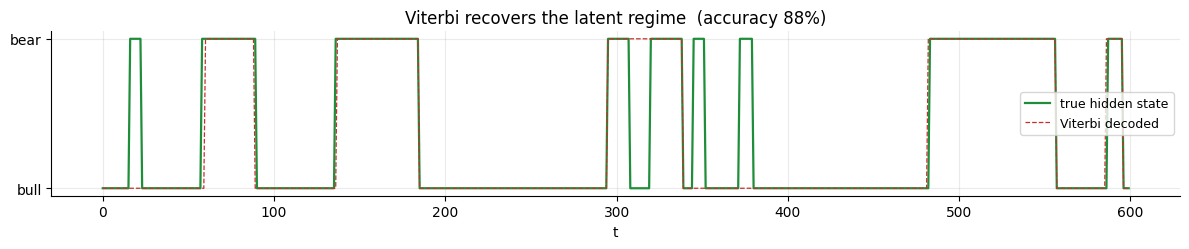

In [7]:
seg = slice(0, 600)
fig, ax = plt.subplots(figsize=(12, 2.6))
ax.plot(true_states[seg], color='#1f8e3a', lw=1.6, label='true hidden state')
ax.plot(path_aligned[seg], color='#c4302b', lw=0.9, ls='--', label='Viterbi decoded')
ax.set_yticks([0, 1]); ax.set_yticklabels(['bull', 'bear'])
ax.set_title(f'Viterbi recovers the latent regime  (accuracy {acc:.0%})')
ax.set_xlabel('t'); ax.legend(fontsize=9, loc='center right')
plt.tight_layout(); plt.show()


## 5. Unsupervised regime detection on SPY

The pay-off: fit an HMM to **real** SPY returns (discretised into
down/flat/up terciles) with *no labels at all*, then decode the hidden state.
The model discovers — unsupervised — the classic **two-regime** structure:

* a **calm/bull** state: positive average return, low volatility, persistent;
* a **crisis/bear** state: negative average return, high volatility.

We shade the decoded crisis periods over the price — they line up with the known
drawdowns (2008, 2020, 2022).


In [8]:
def load_spy(start='2005-01-01', end='2024-12-31'):
    try:
        import yfinance as yf
        s = yf.download('SPY', start=start, end=end, auto_adjust=True, progress=False)
        s = s['Close'].dropna().to_numpy(dtype='float64').ravel()
        if len(s) > 1000:
            return s
    except Exception as exc:
        print(f'yfinance unavailable ({exc!r}); using synthetic SPY')
    return 100 * np.exp(np.cumsum(np.random.default_rng(2).normal(0.0003, 0.011, 4000)))

spy = load_spy()
ret = np.diff(np.log(spy))
edges = np.quantile(ret, [1/3, 2/3])             # down / flat / up terciles
obs_spy = np.digitize(ret, edges).astype(np.intp)

hmm = fit_hmm(obs_spy, n_states=2, n_obs_symbols=3, n_init=10,
              rng=np.random.default_rng(3))
states = decode(obs_spy, hmm)

# Identify which decoded state is the 'crisis' one (lower mean, higher vol).
means = [ret[states == k].mean() for k in range(2)]
vols = [ret[states == k].std() for k in range(2)]
crisis = int(np.argmin(means))
print(f'log-lik={hmm.log_likelihood:.0f}  converged={hmm.converged}')
for k in range(2):
    tag = 'CRISIS/bear' if k == crisis else 'calm/bull'
    frac = np.mean(states == k)
    print(f'  state {k} [{tag:<11}]: mean={means[k]*252*100:+6.1f}%/yr  '
          f'vol={vols[k]*np.sqrt(252)*100:5.1f}%/yr  time={frac:5.1%}')


log-lik=-5422  converged=True
  state 0 [CRISIS/bear]: mean= -12.3%/yr  vol= 28.5%/yr  time=33.0%
  state 1 [calm/bull  ]: mean= +20.7%/yr  vol= 11.9%/yr  time=67.0%


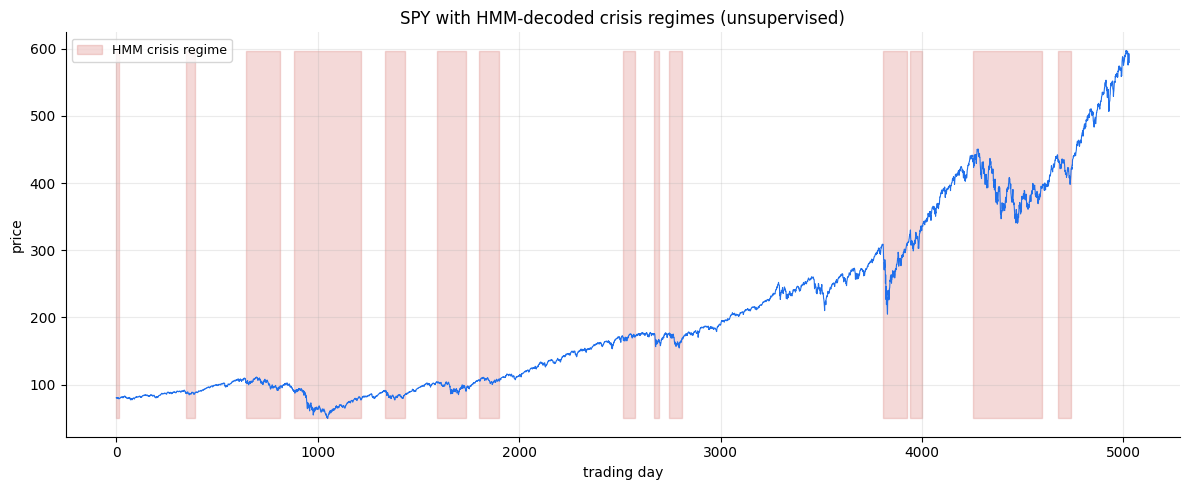

In [9]:
is_crisis = (states == crisis)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(spy[1:], color='#1f6feb', lw=0.8)
ax.fill_between(np.arange(len(spy) - 1), spy.min(), spy.max(),
                where=is_crisis, color='#c4302b', alpha=0.18, label='HMM crisis regime')
ax.set_title('SPY with HMM-decoded crisis regimes (unsupervised)')
ax.set_ylabel('price'); ax.set_xlabel('trading day'); ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()


## What next?

* **Continuous emissions.** Discretising returns throws away information. A
  **Gaussian HMM** (or the **Markov-switching AR** in
  `qufin.timeseries.MarkovSwitchingAR`, see the regime-switching tutorial) models
  the returns directly with state-dependent mean and variance.
* **Trade the regime.** Use the decoded state (or its filtered probability) to
  gate risk: cut exposure or buy protection when $P(\text{crisis})$ rises.
* **Online decoding.** Viterbi here is full-batch (look-ahead). For live use,
  run the forward filter to get the *causal* posterior $P(z_t\mid x_{0:t})$.
* **Order selection.** Compare 2- vs 3-state HMMs by BIC, exactly as we did for
  the higher-order chain — more states always raise the likelihood, so penalise.
